In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
df = pd.read_csv("Crop_recommendation.csv")

print(df.head())
print(df.info())

    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None


In [3]:
# Features and target
X = df.drop('label', axis=1)
y = df['label']

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

RandomForestClassifier()

In [6]:
y_pred = model.predict(X_test)

In [7]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 0.9931818181818182
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        17
           7       1.00      1.00      1.00        14
           8       0.92      1.00      0.96        23
           9       1.00      1.00      1.00        20
          10       0.92      1.00      0.96        11
          11       1.00      1.00      1.00        21
          12       1.00      1.00      1.00        19
          13       1.00      0.96      0.98        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00        1

In [8]:
# Example input
sample = [[90, 40, 40, 25, 80, 6.5, 200]]

prediction = model.predict(sample)
crop_name = le.inverse_transform(prediction)

print("Recommended Crop:", crop_name[0])

Recommended Crop: rice


C:\Users\REA\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


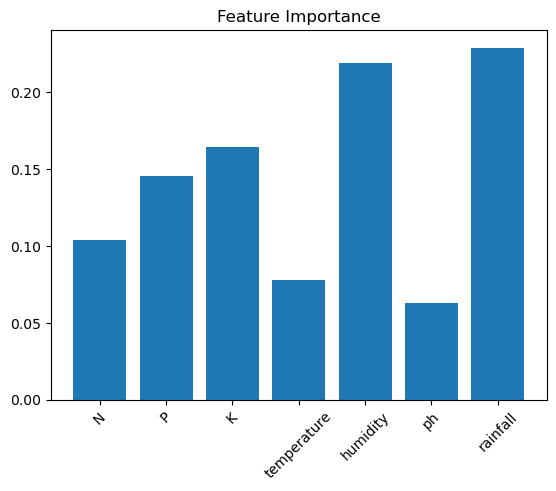

In [9]:
import matplotlib.pyplot as plt

importances = model.feature_importances_

plt.bar(X.columns, importances)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

In [10]:
import streamlit as st

st.title("Crop Recommendation System")

N = st.number_input("Nitrogen")
P = st.number_input("Phosphorus")
K = st.number_input("Potassium")
temp = st.number_input("Temperature")
humidity = st.number_input("Humidity")
ph = st.number_input("pH")
rainfall = st.number_input("Rainfall")

if st.button("Predict"):
    input_data = [[N, P, K, temp, humidity, ph, rainfall]]
    result = model.predict(input_data)
    crop = le.inverse_transform(result)
    st.success(f"Recommended Crop: {crop[0]}")

2026-03-25 10:38:47.257 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 10:38:48.735 
  command:

    streamlit run C:\Users\REA\anaconda\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-25 10:38:48.737 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 10:38:48.739 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 10:38:48.740 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 10:38:48.742 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 10:38:48.744 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 10:38:48.745 Session state does not fun